# CROCUS Precipitation

Precipitation data access and cross-validation for CROCUS Sage/Waggle nodes.
Two independent sensors are available at most sites, operating on different
physical principles:

| Function | Sensor | Principle |
|---|---|---|
| `query_raingauge` | Hydreon RG-15 | Optical (infrared drop detection) |
| `query_wxt` | Vaisala WXT536 | Acoustic (piezoelectric) |
| `query_asos` | ASOS network | Heated tipping bucket / optical |
| `query_cocorahs` | CoCoRaHS volunteers | Manual wedge gauge (daily) |

## References
- Hydreon RG-15: https://rainsensors.com/products/rg-15/
- Vaisala WXT536: https://www.vaisala.com/en/products/weather-environmental-sensors/weather-transmitter-wxt530-series
- ASOS: https://www.weather.gov/asos
- Iowa Environmental Mesonet: https://mesonet.agron.iastate.edu/
- CoCoRaHS: https://www.cocorahs.org/

In [1]:
# Standard library
import ssl

# Third party
import matplotlib.pyplot as plt
import pandas as pd

# Local
import importlib
import crocus_sites
importlib.reload(crocus_sites)
import sage_utils
importlib.reload(sage_utils)
import crocus_precip
importlib.reload(crocus_precip)

from crocus_sites import (
    ALL_SITES,
    ATMOS, BIG, CCICS, CSU,
    HUM, NEIU, NU, SHEDD, UIC,
)
from sage_utils import query_wxt, last_n_hours
from crocus_precip import query_raingauge, query_asos, query_cocorahs

ssl._create_default_https_context = ssl._create_unverified_context


In [2]:
SITE = CSU
# START, END = last_n_hours(24 * 90)  # last 90 days
START = "2026-03-01"  # start is at the beginning of this day
END   = "2026-05-26"  # end is at the beginning of this day

## Optical Rain Sensor: Hydreon RG-15

The RG-15 uses infrared LED drop detection to measure rain rate and accumulation
at ~30 second resolution during active rain events. It reports only when rain
is detected — dry periods return no data.

**Known issues:**
- Susceptible to direct solar interference at specific sun angles — see
  `crocus_rg15_qc.ipynb` for site-specific artifact analysis
- CSU (W08E): RG-15 appears to under-count relative to WXT — sensor may need
  inspection or replacement
- HUM (W0A1): RG-15 stopped reporting ~April 2026 — RPi may need reboot

The WXT rain accumulation is queried over the same window as a cross-check.
RG-15 spikes with no corresponding WXT signal are artifact candidates.

In [3]:
if SITE.has_raingauge:
    # WXT rain.accumulation is a running total --- finer resampling won't improve
    # the derived rate since post-2026 WXT native resolution is already 5 min.
    # Change WXT_RESAMPLE to '1min' or '2min' only if querying pre-2026 data.
    WXT_RESAMPLE = "5min"

    rain = query_raingauge(SITE, START, END)  # native ~30s, no resampling

    # Also pull WXT over the same window for rain cross-check
    wxt_rain = pd.DataFrame()
    if SITE.has_wxt:
        wxt_rain = query_wxt(SITE, START, END, resample=WXT_RESAMPLE)

    if rain.empty:
        print(f"No rain events recorded at {SITE.abbr} in the last 90 days.")
    else:
        has_wxt_rain = (
            not wxt_rain.empty
            and "rain" in wxt_rain.columns
            and wxt_rain["rain"].notna().any()
        )

        # Derive WXT rain rate from accumulation diff (mm per interval → mm/hr)
        if has_wxt_rain:
            interval_minutes = pd.tseries.frequencies.to_offset(WXT_RESAMPLE).nanos / 6e10
            wxt_rain["rain_rate"] = (
                wxt_rain["rain"]
                .diff()
                .clip(lower=0)          # drop negative diffs (counter resets)
                / (interval_minutes / 60)
            )

        nrows = 3 if has_wxt_rain else 2
        fig, axes = plt.subplots(nrows, 1, figsize=(12, 4 * nrows), sharex=True)
        ax1, ax2 = axes[0], axes[1]
        ax3 = axes[2] if has_wxt_rain else None

        # --- Panel 1: RG-15 rain rate + WXT derived rate ---
        ax1.plot(rain.index, rain["rint"],
                 color="steelblue", linewidth=0.8, alpha=0.6,
                 label="RG-15 rain rate (mm/hr)")
        if has_wxt_rain:
            ax1.plot(wxt_rain.index, wxt_rain["rain_rate"],
                     color="darkorange", linewidth=1.2, alpha=0.6,
                     label=f"WXT derived rate ({WXT_RESAMPLE} diff, mm/hr)")
        ax1.set_ylabel("Rain Rate (mm/hr)")
        ax1.legend(loc="upper left", fontsize=8)
        ax1.set_ylim(bottom=0)
        ax1.grid(True, alpha=0.3)

        # --- Panel 2: RG-15 event accumulation ---
        ax2.plot(rain.index, rain["event_acc"],
                 color="#08306b", linewidth=0.8, alpha=0.6,
                 label="RG-15 event acc (mm)")
        ax2.set_ylabel("Event Accumulation (mm)")
        ax2.legend(loc="upper left", fontsize=8)
        ax2.set_ylim(bottom=0)
        ax2.grid(True, alpha=0.3)

        # --- Panel 3: WXT cumulative accumulation ---
        if has_wxt_rain:
            ax3.plot(wxt_rain.index, wxt_rain["rain"],
                     color="darkorange", linewidth=0.8, alpha=0.6,
                     label="WXT cumulative acc (mm)")
            ax3.set_ylabel("WXT Cumul. Acc (mm)")
            ax3.set_xlabel("Time (UTC)")
            ax3.legend(loc="upper left", fontsize=8)
            ax3.set_ylim(bottom=0)
            ax3.grid(True, alpha=0.3)
            ax3.set_title(
                "WXT cumulative accumulation — steps confirm real rain events; "
                "flat during RG-15 spikes = optical artifact",
                fontsize=8, loc="left", color="0.4"
            )
        else:
            ax2.set_xlabel("Time (UTC)")
            if SITE.has_wxt:
                print("WXT data returned no rain column — skipping cross-check panel.")

        fig.suptitle(f"RG-15 Rain Gauge — {SITE.abbr} ({SITE.vsn})", fontsize=12)
        fig.tight_layout()
        plt.savefig(f"figures/{SITE.abbr}_rain.png", dpi=150, bbox_inches="tight")
        plt.show()

else:
    print(f"{SITE.abbr} has no rain gauge configured.")

HTTPError: HTTP Error 500: Internal Server Error

## ASOS Cross-Validation

Hourly precipitation from the nearest Automated Surface Observing System (ASOS)
airport station, fetched from the Iowa Environmental Mesonet (IEM). Typically
returns in a few seconds.

ASOS provides an independent reference on a different physical platform than
either the RG-15 or WXT. Useful for confirming real rain events and identifying
RG-15 artifacts &mdash; genuine precipitation should appear in both ASOS and the
CROCUS sensors; RG-15-only signals without ASOS confirmation are suspect.

Note that ASOS stations are several km from CROCUS nodes &mdash; localized convective
cells may produce precipitation at one location but not the other.

- Iowa Environmental Mesonet ASOS explorer: https://mesonet.agron.iastate.edu/explorer/
- FAA ASOS description: https://www.faa.gov/air_traffic/weather/asos
- NWS ASOS page: https://www.weather.gov/asos

Trying ASOS station: KMDW (41.7859, -87.7524)
  Using KMDW


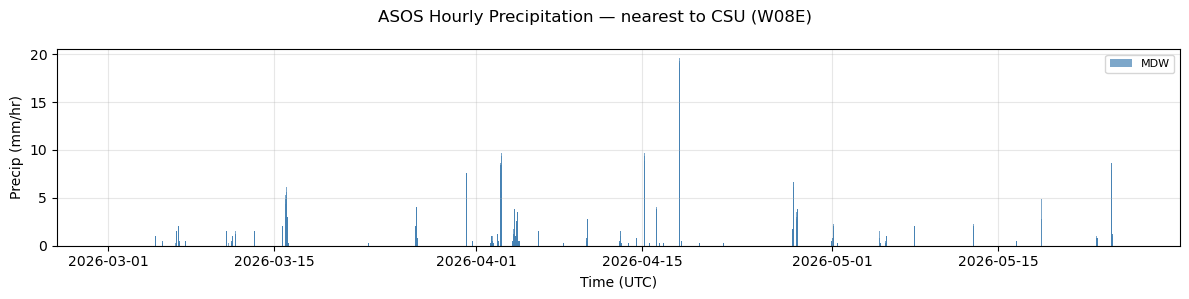

In [ ]:
asos = query_asos(SITE, START, END)

if not asos.empty:
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.bar(asos.index, asos['precip_mm'],
           width=pd.Timedelta('1h'), color='steelblue',
           alpha=0.7, label=asos['station'].iloc[0])
    ax.set_ylabel('Precip (mm/hr)')
    ax.set_xlabel('Time (UTC)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)
    fig.suptitle(f'ASOS Hourly Precipitation — nearest to {SITE.abbr} ({SITE.vsn})',
                 fontsize=12)
    fig.tight_layout()
    plt.savefig(f"figures/{SITE.abbr}_asos.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No ASOS data returned.")

## CoCoRaHS Cross-Validation

Daily precipitation totals from the nearest CoCoRaHS volunteer observers,
fetched from the Iowa Environmental Mesonet (IEM). Station locations are
discovered via the NOAA GHCND station metadata file (cached after first call),
then data is retrieved from IEM.

CoCoRaHS observers report a 24-hour manual gauge reading ending at 7 AM local
time — not directly comparable to the continuous RG-15 or WXT record, but
useful for event-total validation.

**Current status:** Chicago-area CoCoRaHS volunteer activity is sparse.
`US1ILCK0395` (NEIU Physics, 0.05 km from the NEIU node) is inactive pending
student participation. UIC-area stations are also currently inactive.
The query will return an empty DataFrame if no observations were submitted
in the requested period.

- CoCoRaHS: https://www.cocorahs.org/
- IEM CoCoRaHS viewer: https://mesonet.agron.iastate.edu/cocorahs/

In [ ]:
cocorahs = query_cocorahs(SITE, START, END, n_stations=3)
cocorahs

Nearest CoCoRaHS stations to CSU:
    STATION                    NAME  DIST_KM
US1ILCK0108           BEVERLY 0.3 N 4.839928
US1ILCK0342 MERRIONETTE PARK 1.7 NE 5.728915
US1ILCK0151   EVERGREEN PARK 0.5 NE 6.860511
CoCoRaHS stations found but no observations reported in this period.
Stations checked: IL-CK-108, IL-CK-342, IL-CK-151


""


In [ ]:
if cocorahs.empty:
    print("No CoCoRaHS data returned.")
else:
    fig, ax = plt.subplots(figsize=(12, 4))

    for station_id, grp in cocorahs.groupby('station'):
        name  = grp['name'].iloc[0]
        dist  = grp['dist_km'].iloc[0]
        label = f"{name} ({dist:.1f} km)"
        ax.bar(grp.index, grp['precip_mm'],
               label=label, alpha=0.6, width=0.8)

    # Overlay RG-15 daily total for comparison if available
    if 'rain' in dir() and not rain.empty:
        rg_daily = rain['event_acc'].resample('D').max().diff().clip(lower=0)
        ax.step(rg_daily.index, rg_daily.values,
                where='mid', color='steelblue', linewidth=1.5,
                label='RG-15 daily acc (approx, mm)', zorder=5)

    ax.set_ylabel('Precipitation (mm)')
    ax.set_xlabel('Date')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)
    fig.suptitle(
        f'CoCoRaHS Daily Precipitation near {SITE.abbr} ({SITE.vsn})',
        fontsize=12
    )
    fig.tight_layout()
    plt.savefig(f"figures/{SITE.abbr}_cocorahs.png", dpi=150, bbox_inches="tight")
    plt.show()


No CoCoRaHS data returned.


## Combined Precipitation Overview

Two-panel summary for direct cross-validation between the CROCUS sensors
(RG-15 + WXT, top) and the nearest ASOS station (bottom) over the same
time window. Both panels show hourly accumulation in mm on a common y-scale.

Rain events confirmed by both sensors appear as overlapping bars in the top
panel and corresponding bars in the bottom panel at the same dates.
RG-15-only signals with no ASOS echo are artifact candidates — see
`crocus_rg15_qc.ipynb` for detailed artifact analysis.

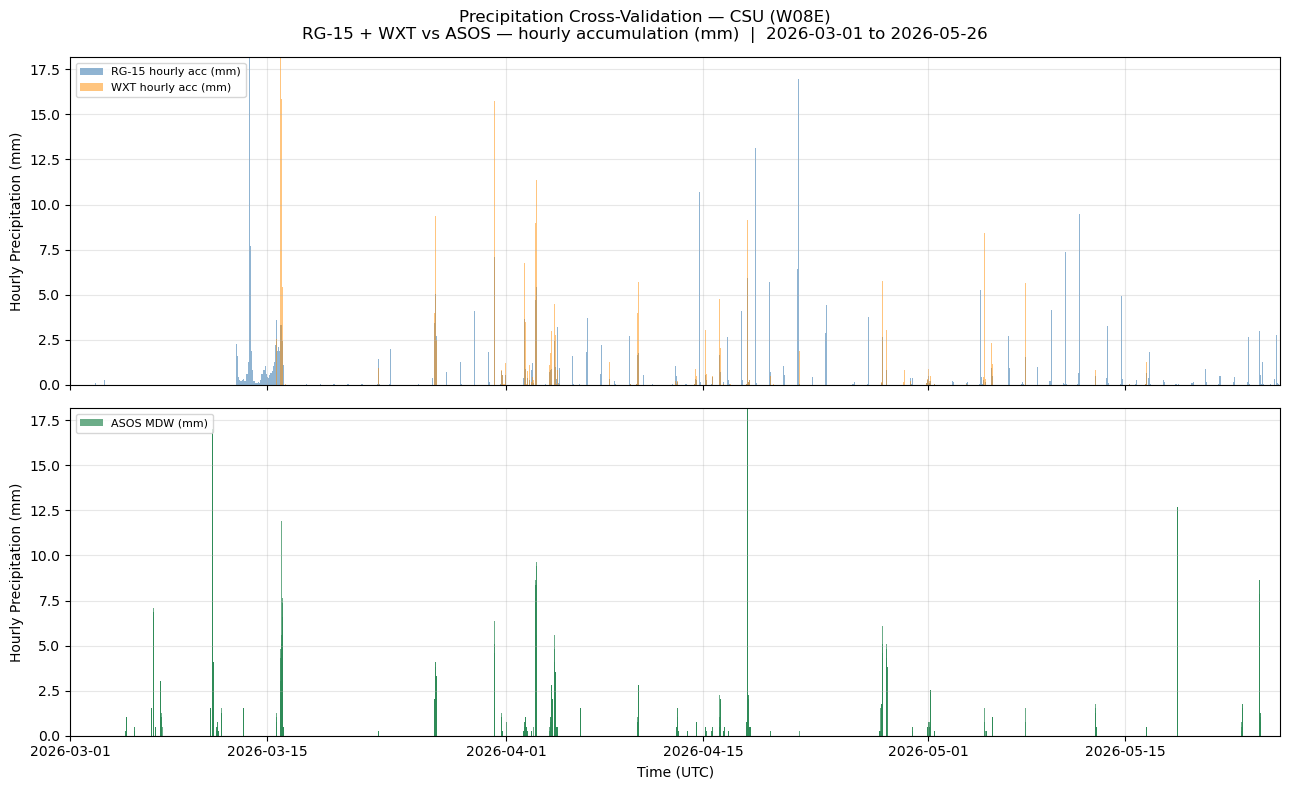

In [ ]:
have_rain = 'rain' in dir() and not rain.empty
have_asos = 'asos' in dir() and not asos.empty

if not have_rain and not have_asos:
    print("No precipitation data available for combined plot.")
else:
    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, figsize=(13, 8), sharex=True
    )

    # --- Top panel: RG-15 + WXT hourly accumulation ----------------------
    if have_rain:
        rg_hourly = (
            rain['event_acc']
            .resample('1h').max()
            .diff()
            .clip(lower=0)
        )
        ax_top.bar(rg_hourly.index, rg_hourly.values,
                   width=pd.Timedelta('1h'), color='steelblue',
                   alpha=0.6, label='RG-15 hourly acc (mm)')
        if has_wxt_rain:
            wxt_hourly = (
                wxt_rain['rain']
                .resample('1h').max()
                .diff()
                .clip(lower=0)
            )
            ax_top.bar(wxt_hourly.index, wxt_hourly.values,
                       width=pd.Timedelta('1h'), color='darkorange',
                       alpha=0.5, label='WXT hourly acc (mm)')

    # --- Bottom panel: ASOS hourly accumulation --------------------------
    if have_asos:
        asos_label = asos['station'].iloc[0]
        ax_bot.bar(asos.index, asos['precip_mm'],
                   width=pd.Timedelta('1h'), color='seagreen',
                   alpha=0.7, label=f'ASOS {asos_label} (mm)')

    # Common y scale — 99th percentile of rainy hours only
    all_values = pd.concat([
        rg_hourly.dropna() if have_rain else pd.Series(dtype=float),
        wxt_hourly.dropna() if have_rain and has_wxt_rain else pd.Series(dtype=float),
        asos['precip_mm'].dropna() if have_asos else pd.Series(dtype=float),
    ])
    rainy = all_values[all_values > 0.1]
    y_max = rainy.quantile(0.99) * 1.1 if not rainy.empty else 10

    ax_top.set_ylim(bottom=0, top=y_max)
    ax_bot.set_ylim(bottom=0, top=y_max)

    ax_top.set_ylabel('Hourly Precipitation (mm)')
    ax_top.legend(loc='upper left', fontsize=8)
    ax_top.grid(True, alpha=0.3)

    ax_bot.set_ylabel('Hourly Precipitation (mm)')
    ax_bot.set_xlabel('Time (UTC)')
    ax_bot.legend(loc='upper left', fontsize=8)
    ax_bot.grid(True, alpha=0.3)

    # Enforce common x limits from START/END
    x_min = pd.to_datetime(START, utc=True)
    x_max = pd.to_datetime(END,   utc=True)
    ax_top.set_xlim(x_min, x_max)

    fig.suptitle(
        f'Precipitation Cross-Validation — {SITE.abbr} ({SITE.vsn})\n'
        f'RG-15 + WXT vs ASOS — hourly accumulation (mm)  |  {START} to {END}',
        fontsize=12
    )
    fig.tight_layout()
    plt.savefig(f"figures/{SITE.abbr}_precip_validation.png",
                dpi=150, bbox_inches='tight')
    plt.show()